# 06 — Market Coupling: Germany's Impact on Neighbors

**Evaluation: Originality** — A fresh angle: Which neighboring countries does Germany affect the most in terms of spot price? When does coupling happen?

European markets are coupled: prices converge when interconnectors allow arbitrage. We analyze price correlation and flow patterns to identify when DE drives neighbor prices.

In [20]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data_loader import load_all_spot_prices, load_flows_into, load_spot_price

## Price correlation matrix (DE vs neighbors)

DE spot price correlation with neighbors:
NL     0.959636
DK1    0.926731
CZ     0.920064
BE     0.913555
AT     0.911634
PL     0.776516
CH     0.744029
FR     0.706911
Name: DE, dtype: float64


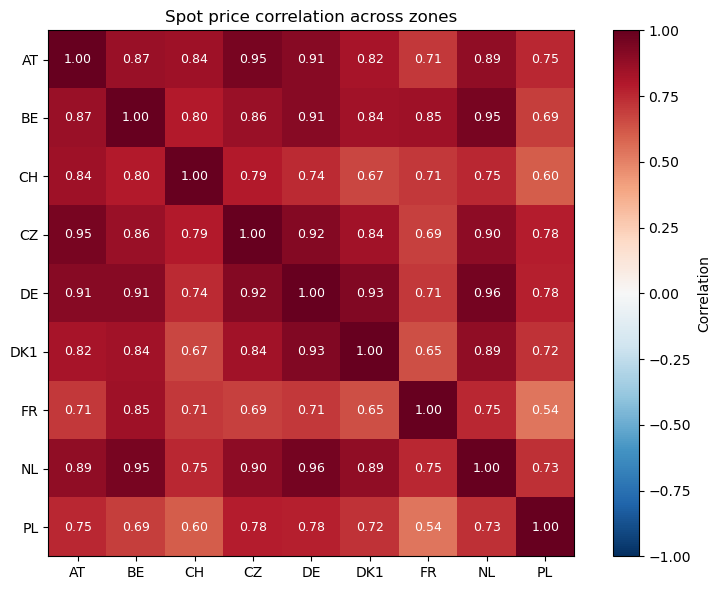

In [23]:
prices = load_all_spot_prices()
if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(0)

# Resample to 15-min: expand hourly data with ffill
full_idx = pd.date_range(prices.index.min(), prices.index.max(), freq="15min", tz="UTC")
prices_15 = prices.reindex(full_idx).ffill()

corr = prices_15.corr()

# DE's correlation with each neighbor
de_corr = corr["DE"].drop("DE").sort_values(ascending=False)
print("DE spot price correlation with neighbors:")
print(de_corr)

# Show lower triangle only (symmetric matrix)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # mask upper triangle
corr_masked = corr.mask(mask)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

# Add correlation values to each cell
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)

plt.colorbar(im, label="Correlation")
plt.title("Spot price correlation across zones")
plt.tight_layout()
plt.show()

## Price spread: DE vs neighbor (when does coupling break?)

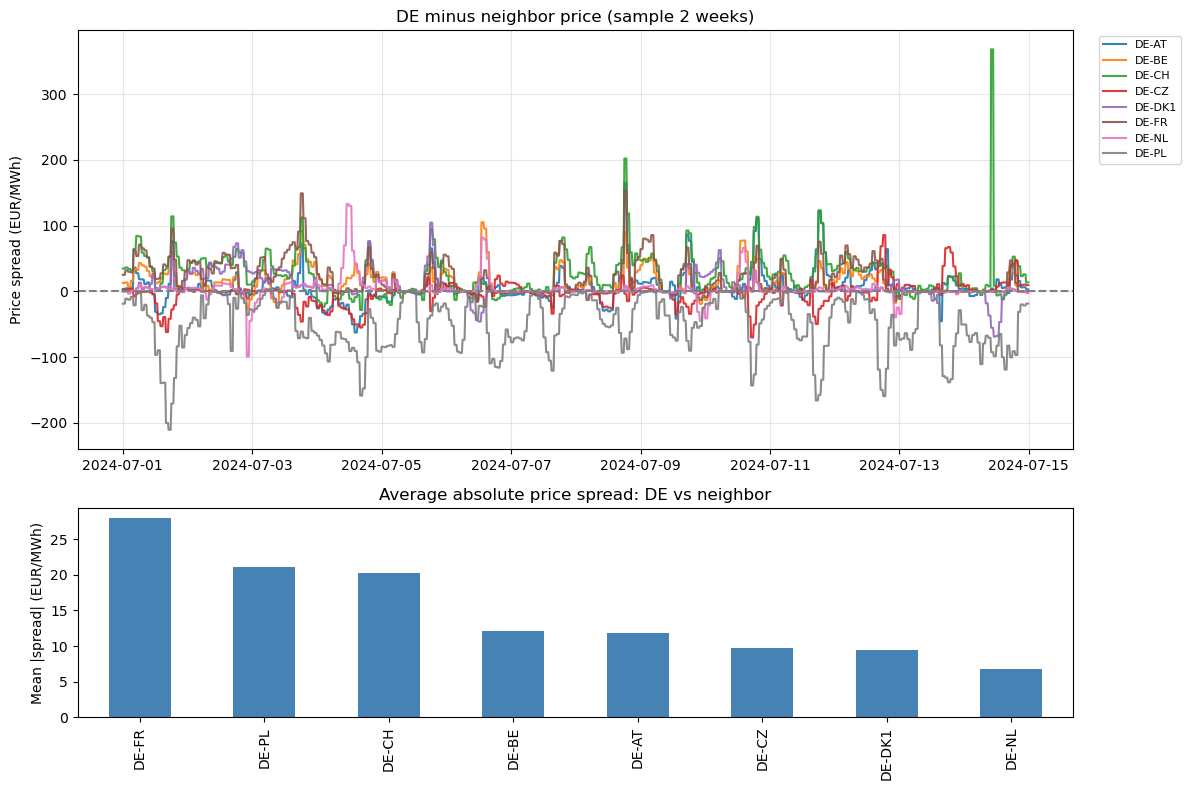

In [24]:
# Price spread = DE - neighbor. Large spread → uncoupled (congestion)
neighbors = [z for z in prices_15.columns if z != "DE"]
spreads = pd.DataFrame({f"DE-{z}": prices_15["DE"] - prices_15[z] for z in neighbors})

fig, axes = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[2, 1])
sample = spreads.loc["2024-07-01":"2024-07-14"].copy()

# Matplotlib can struggle with timezone-aware index; use naive for plotting
if sample.index.tz is not None:
    sample.index = sample.index.tz_localize(None)

for col in sample.columns:
    axes[0].plot(sample.index, sample[col], label=col, alpha=0.9, linewidth=1.5)
axes[0].axhline(0, color="gray", ls="--")
# Fixed y-axis: typical spread is ±80 EUR/MWh (outliers clipped for visibility)
# axes[0].set_ylim(-80, 80)
axes[0].set_ylabel("Price spread (EUR/MWh)")
axes[0].set_title("DE minus neighbor price (sample 2 weeks)")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
axes[0].grid(True, alpha=0.3)

# Distribution of spreads
spreads.abs().mean().sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_ylabel("Mean |spread| (EUR/MWh)")
axes[1].set_title("Average absolute price spread: DE vs neighbor")
plt.tight_layout()
plt.show()

## Flow direction and price alignment

In [25]:
# When DE exports to X, DE price should be <= X price (arbitrage)
# When DE imports from X, DE price should be >= X price
flows_de = load_flows_into("DE")
pivot = flows_de.pivot(index="time", columns="zone", values="value (MW)")
pivot.index = pd.to_datetime(pivot.index, utc=True)
# Resample flows to 15-min (reindex + ffill for hourly/mixed granularity)
full_idx = pd.date_range(pivot.index.min(), pivot.index.max(), freq="15min", tz="UTC")
pivot = pivot.reindex(full_idx).ffill()

join = pivot.join(prices_15, how="inner")

# FR->DE: positive = flow into DE (France exporting to DE)
# When FR exports to DE, FR price < DE price typically
if "FR->DE" in join.columns and "FR" in join.columns:
    fr_export = join["FR->DE"] > 0  # France exporting to DE
    subset = join[fr_export].dropna(subset=["DE", "FR"])
    pct_correct = (subset["FR"] <= subset["DE"]).mean() * 100
    print(f"When FR exports to DE: FR price <= DE price in {pct_correct:.1f}% of 15-min intervals")
    print("(Arbitrage: power flows from low-price to high-price region)")

When FR exports to DE: FR price <= DE price in 77.3% of 15-min intervals
(Arbitrage: power flows from low-price to high-price region)
